# 建筑能耗预测（Random Forest + LSTM）

这个 Notebook 会用同一份数据分别训练两种模型来预测建筑能耗（这里用 `Power` 作为能耗/功率目标）：

- **随机森林（RandomForestRegressor）**：用“很多决策树投票”的方法，适合表格特征预测  
- **LSTM**：用“序列记忆”的方法，适合时间序列预测（用过去一段时间的数据预测下一时刻）

> 你只需要把本 Notebook 跑一遍，就能得到两种模型的预测结果与评估指标。  
> 你也可以自己改 `LOOK_BACK`、`TEST_RATIO`、`EPOCHS` 等参数做实验。


In [1]:
# 安装/导入依赖
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

# 深度学习（LSTM）
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


C:\Users\tianz\miniconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# 读取数据
DATA_PATH = "building_energy.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
display(df.head())

# 一些清理：去掉无用的索引列
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# 时间列转成 datetime 并按时间排序
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("columns:", df.columns.tolist())
display(df.tail())


shape: (17544, 9)


,Unnamed: 0,timestamp,Power,airTemperature,dewTemperature,windSpeed,hour,day_of_week,month
0,0,2016-01-01 00:00:00,174.0850,1.9,-1.2,5.0,0,4,1
1,1,2016-01-01 01:00:00,175.1750,1.6,-1.5,3.0,1,4,1
2,2,2016-01-01 02:00:00,175.8725,0.7,-1.8,3.0,2,4,1
3,3,2016-01-01 03:00:00,169.0675,0.8,-2.1,4.0,3,4,1
4,4,2016-01-01 04:00:00,191.5025,2.9,-1.6,3.0,4,4,1


columns: ['timestamp', 'Power', 'airTemperature', 'dewTemperature', 'windSpeed', 'hour', 'day_of_week', 'month']


,timestamp,Power,airTemperature,dewTemperature,windSpeed,hour,day_of_week,month
17539,2017-12-31 19:00:00,194.0300,4.4,2.4,8.0,19,6,12
17540,2017-12-31 20:00:00,186.9400,4.0,2.0,8.0,20,6,12
17541,2017-12-31 21:00:00,181.7150,4.4,1.6,11.0,21,6,12
17542,2017-12-31 22:00:00,176.6925,4.2,1.2,12.0,22,6,12
17543,2017-12-31 23:00:00,173.7275,3.8,1.3,12.0,23,6,12


## 目标列 & 特征列

- **目标（y）**：`Power`
- **特征（X）**：除 `timestamp` 和 `Power` 以外的列

如果你的数据里未来改了列名，只要在这里改一下 `TARGET_COL` 就行。


In [3]:
TARGET_COL = "Power"

assert TARGET_COL in df.columns, f"找不到目标列 {TARGET_COL}，当前列有：{df.columns.tolist()}"

feature_cols = [c for c in df.columns if c not in ["timestamp", TARGET_COL]]
print("feature_cols:", feature_cols)

X_all = df[feature_cols].copy()
y_all = df[TARGET_COL].copy()


feature_cols: ['airTemperature', 'dewTemperature', 'windSpeed', 'hour', 'day_of_week', 'month']


# Part A：随机森林（Random Forest）

随机森林不需要“序列窗口”，它把每一行当作一个样本，用特征去预测 `Power`。
我们用**时间顺序切分**：前面做训练，后面做测试（更符合真实预测）。


In [4]:
# 时间顺序切分
TEST_RATIO = 0.2
n = len(df)
n_test = int(n * TEST_RATIO)

X_train_rf = X_all.iloc[:-n_test]
y_train_rf = y_all.iloc[:-n_test]
X_test_rf  = X_all.iloc[-n_test:]
y_test_rf  = y_all.iloc[-n_test:]

print("train:", X_train_rf.shape, "test:", X_test_rf.shape)


train: (14036, 6) test: (3508, 6)


In [5]:
# 把 X 和 y 合在一起（用你现在已有的 x_all, y_all）
df_rf = X_all.copy()
df_rf["target"] = y_all

# 删除 target 里是 NaN 的行
df_rf = df_rf.dropna()

# 再拆开
X_all_clean = df_rf.drop(columns=["target"])
y_all_clean = df_rf["target"]

# 重新切分训练/测试（对齐清理后的数据）
n = len(df_rf)
n_test = int(n * TEST_RATIO)
X_train_rf = X_all_clean.iloc[:-n_test]
y_train_rf = y_all_clean.iloc[:-n_test]
X_test_rf  = X_all_clean.iloc[-n_test:]
y_test_rf  = y_all_clean.iloc[-n_test:]

print("clean train:", X_train_rf.shape, "test:", X_test_rf.shape)


clean train: (13990, 6) test: (3497, 6)


In [6]:
# 训练随机森林
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)

rf_mse = mean_squared_error(y_test_rf, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
mae = mean_absolute_error(y_test_rf, y_pred_rf)
mbe = (y_test_rf.values - y_pred_rf).mean()
corr = np.corrcoef(y_test_rf.values, y_pred_rf)[0,1]
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test_rf, y_pred_rf)
print("RF 评估：")
print("  RMSE:", rmse)
print("  MAE :", mae)
print("  MBE :", mbe)
print("  Corr:", corr)
print("   R²:", r2_rf)


RF 评估：
  RMSE: 44.3118403358656
  MAE : 28.42023219845582
  MBE : -2.667262717472097
  Corr: 0.8007012019307779
   R²: 0.6109626322243589


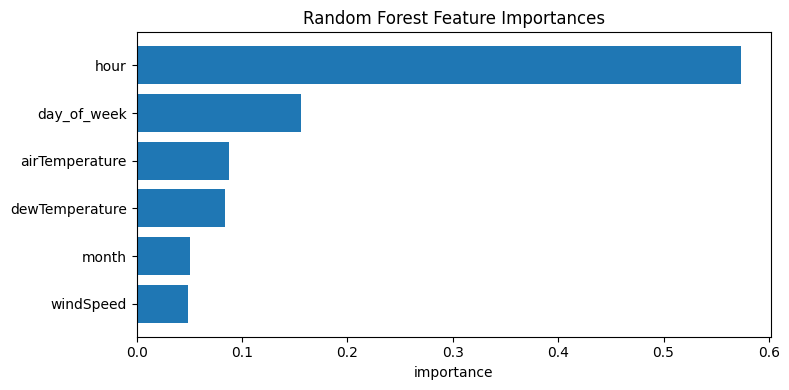

In [7]:
# 特征重要性（看看哪些因素更影响能耗）
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importances.index, importances.values)
plt.title("Random Forest Feature Importances")
plt.xlabel("importance")
plt.tight_layout()
plt.show()


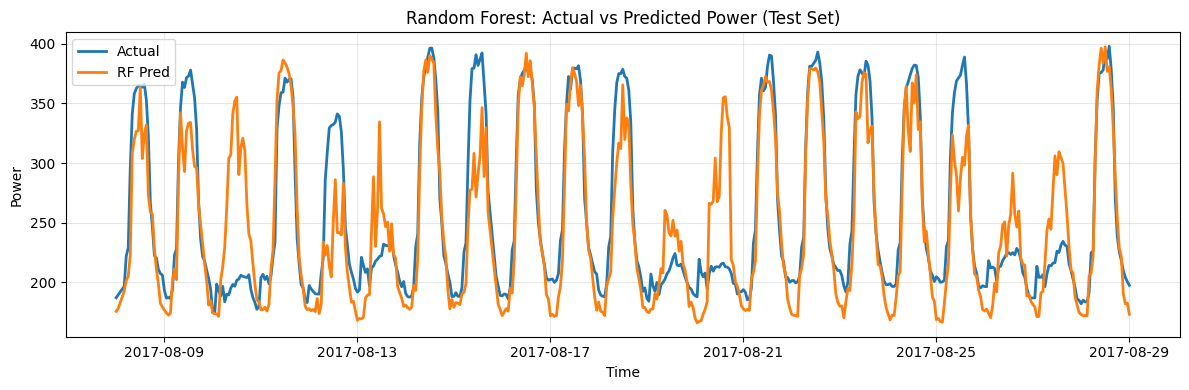

In [8]:
# ========= 用真实时间画 RF 预测 vs 真实 =========

# 取测试集对应的时间（和 y_test_rf 对齐）
time_test = df.loc[y_test_rf.index, "timestamp"]

# 只画前 N 个点，防止太挤
plot_points = min(500, len(y_test_rf))

plt.figure(figsize=(12,4))

plt.plot(
    time_test.iloc[:plot_points],
    y_test_rf.values[:plot_points],
    label="Actual",
    linewidth=2
)

plt.plot(
    time_test.iloc[:plot_points],
    y_pred_rf[:plot_points],
    label="RF Pred",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Random Forest: Actual vs Predicted Power (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Part B：LSTM（时间序列）

LSTM 需要把数据变成“序列窗口”：

- 用过去 `LOOK_BACK` 个小时的数据（包含特征和过去的 Power）
- 去预测下一小时的 `Power`

> 你可以把 `LOOK_BACK=24` 理解成：用过去 24 小时来预测下一小时。


In [9]:
# ===== 网格搜索 + 早停参数 =====
# 针对时序特征，引入滑动窗口机制重构输入序列
# 通过网格搜索优化 LSTM 的时间步长与隐藏层维度
LOOK_BACK_LIST = [12, 24, 48]      # 窗口大小（时间步长）
HIDDEN_DIM_LIST = [64, 128, 256]   # LSTM 隐藏层维度
BATCH_SIZE = 64


In [10]:
# 为了让 LSTM 既看到天气等特征，也看到过去的 Power，
# 我们把 [feature_cols + Power] 一起作为输入序列
seq_df = df[feature_cols + [TARGET_COL]].copy()

for c in seq_df.columns:
    seq_df[c] = pd.to_numeric(seq_df[c], errors="coerce")

seq_df = seq_df.dropna().reset_index(drop=True)

scaler = MinMaxScaler()
seq_scaled = scaler.fit_transform(seq_df.values).astype("float32")

# 滑动窗口函数
def make_windows(data_2d, look_back, target_index):
    X, y = [], []
    for i in range(len(data_2d) - look_back):
        X.append(data_2d[i:i+look_back, :])
        y.append(data_2d[i+look_back, target_index])
    return np.array(X), np.array(y)

# 反归一化辅助函数
def inverse_power(y_scaled_1d):
    tmp = np.zeros((len(y_scaled_1d), seq_df.shape[1]))
    tmp[:, target_index] = y_scaled_1d
    inv = scaler.inverse_transform(tmp)
    return inv[:, target_index]

target_index = seq_df.columns.get_loc(TARGET_COL)
print(f"序列特征数: {seq_df.shape[1]} (含目标列), 目标列索引: {target_index}")


序列特征数: 7 (含目标列), 目标列索引: 6


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm(look_back, hidden_dim, n_features):
    """根据参数动态构建 LSTM 模型"""
    model = Sequential([
        LSTM(hidden_dim, input_shape=(look_back, n_features)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


In [12]:
# ===== 网格搜索 + 早停策略 =====
search_results = []
best_r2 = -1
best_params = {}
best_model = None
best_history = None

for look_back in LOOK_BACK_LIST:
    # 滑动窗口：用不同的窗口大小重构输入序列
    X_seq, y_seq = make_windows(seq_scaled, look_back, target_index)

    n_seq = len(X_seq)
    n_test_seq = int(n_seq * 0.2)
    X_train = X_seq[:-n_test_seq]
    y_train = y_seq[:-n_test_seq]
    X_test  = X_seq[-n_test_seq:]
    y_test  = y_seq[-n_test_seq:]

    for hidden_dim in HIDDEN_DIM_LIST:
        print(f"\n网格搜索: look_back={look_back}, hidden_dim={hidden_dim}")

        model = build_lstm(look_back, hidden_dim, X_train.shape[-1])

        # 早停策略：验证损失连续 5 轮不降则停止训练并恢复最优权重
        early_stop = EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=0
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=[early_stop],
            shuffle=False
        )

        y_pred = model.predict(X_test, verbose=0).reshape(-1)
        y_test_inv = inverse_power(y_test)
        y_pred_inv = inverse_power(y_pred)
        r2 = r2_score(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        actual_epochs = len(history.history['loss'])

        search_results.append({
            'look_back': look_back, 'hidden_dim': hidden_dim,
            'r2': r2, 'rmse': rmse, 'epochs_used': actual_epochs
        })
        print(f"   R2={r2:.4f}, RMSE={rmse:.2f}, 实际训练轮数={actual_epochs}")

        if r2 > best_r2:
            best_r2 = r2
            best_params = {'look_back': look_back, 'hidden_dim': hidden_dim}
            best_model = model
            best_history = history
            best_y_test = y_test_inv
            best_y_pred = y_pred_inv

print(f"\n最优参数: {best_params}  |  最优 R2: {best_r2:.4f}")



网格搜索: look_back=12, hidden_dim=64


C:\Users\tianz\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   R2=0.9579, RMSE=14.58, 实际训练轮数=19

网格搜索: look_back=12, hidden_dim=128


C:\Users\tianz\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   R2=0.9572, RMSE=14.70, 实际训练轮数=21

网格搜索: look_back=12, hidden_dim=256


...

   R2=0.9453, RMSE=16.61, 实际训练轮数=23

网格搜索: look_back=48, hidden_dim=128


C:\Users\tianz\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   R2=0.9567, RMSE=14.78, 实际训练轮数=17

网格搜索: look_back=48, hidden_dim=256


C:\Users\tianz\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   R2=0.9527, RMSE=15.45, 实际训练轮数=22

最优参数: {'look_back': 24, 'hidden_dim': 64}  |  最优 R2: 0.9625


网格搜索结果（按 R2 降序排列）：


,look_back,hidden_dim,r2,rmse,epochs_used
3,24,64,0.962547,13.755201,20
5,24,256,0.962166,13.825025,23
0,12,64,0.957884,14.581364,19
1,12,128,0.957171,14.704157,21
2,12,256,0.956886,14.753124,17
7,48,128,0.956709,14.776123,17
8,48,256,0.952678,15.448795,22
4,24,128,0.951927,15.583798,17
6,48,64,0.945318,16.606734,23


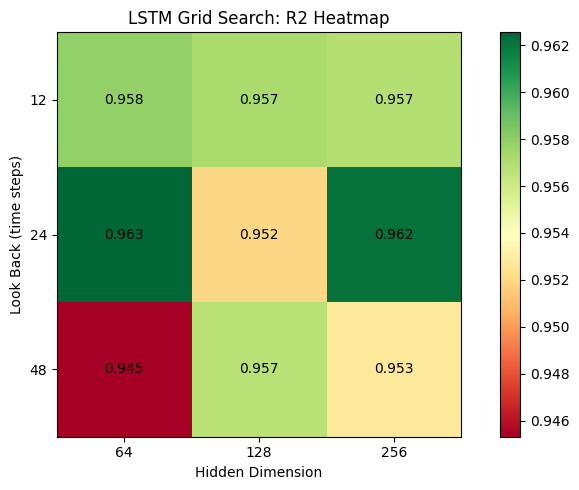

In [13]:
# ===== 网格搜索结果汇总 =====
results_df = pd.DataFrame(search_results).sort_values('r2', ascending=False)
print("网格搜索结果（按 R2 降序排列）：")
display(results_df)

# 参数热力图
pivot = results_df.pivot(index='look_back', columns='hidden_dim', values='r2')
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns); ax.set_yticklabels(pivot.index)
ax.set_xlabel('Hidden Dimension'); ax.set_ylabel('Look Back (time steps)')
ax.set_title('LSTM Grid Search: R2 Heatmap')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.3f}', ha='center', va='center')
plt.colorbar(im)
plt.tight_layout(); plt.show()


最优 LSTM 模型评估 (look_back=24, hidden_dim=64):
  RMSE: 13.7552  MAE: 9.2679  Corr: 0.9827  R2: 0.9625


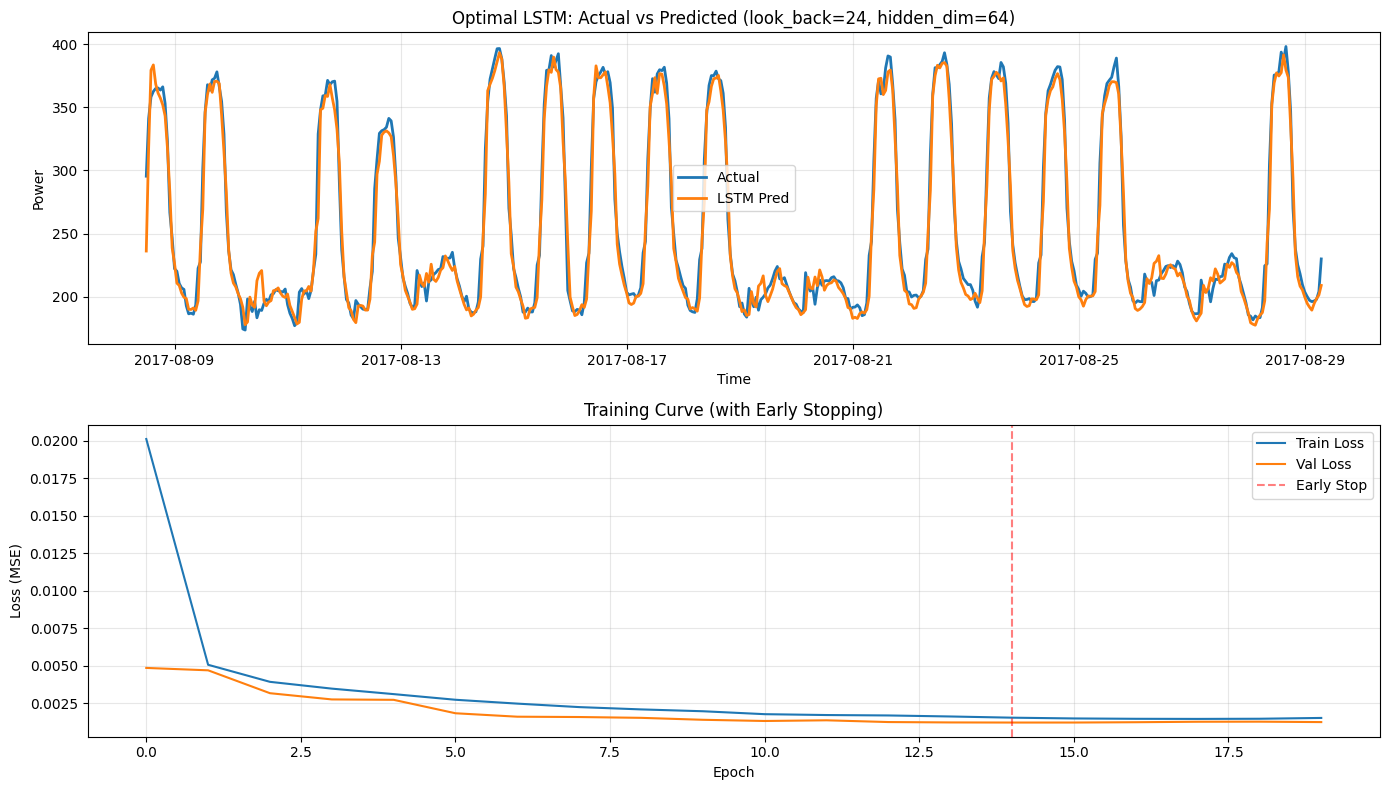


模型对比:
  随机森林  R2: 0.9527   RMSE: 15.45
  LSTM      R2: 0.9625  RMSE: 13.76


In [14]:
# ===== 最优模型：预测 vs 真实值 =====
rmse_lstm = np.sqrt(mean_squared_error(best_y_test, best_y_pred))
mae_lstm = mean_absolute_error(best_y_test, best_y_pred)
corr_lstm = np.corrcoef(best_y_test, best_y_pred)[0, 1]
r2_lstm = r2_score(best_y_test, best_y_pred)

print(f"最优 LSTM 模型评估 (look_back={best_params['look_back']}, hidden_dim={best_params['hidden_dim']}):")
print(f"  RMSE: {rmse_lstm:.4f}  MAE: {mae_lstm:.4f}  Corr: {corr_lstm:.4f}  R2: {r2_lstm:.4f}")

# 预测 vs 真实 + 训练曲线
time_seq = df["timestamp"].iloc[best_params['look_back']:].reset_index(drop=True)
time_test_lstm = time_seq.iloc[-len(best_y_test):].reset_index(drop=True)
plot_points = min(500, len(best_y_test))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(time_test_lstm.iloc[:plot_points], best_y_test[:plot_points], label="Actual", linewidth=2)
axes[0].plot(time_test_lstm.iloc[:plot_points], best_y_pred[:plot_points], label="LSTM Pred", linewidth=2)
axes[0].set_xlabel("Time"); axes[0].set_ylabel("Power")
axes[0].set_title(f"Optimal LSTM: Actual vs Predicted (look_back={best_params['look_back']}, hidden_dim={best_params['hidden_dim']})")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(best_history.history["loss"], label="Train Loss")
axes[1].plot(best_history.history["val_loss"], label="Val Loss")
early_epoch = len(best_history.history["loss"])
axes[1].axvline(x=early_epoch-6, color='r', linestyle='--', alpha=0.5, label='Early Stop')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss (MSE)")
axes[1].set_title("Training Curve (with Early Stopping)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# RF vs LSTM 对比
print(f"\n模型对比:")
print(f"  随机森林  R2: {r2_rf:.4f}   RMSE: {rf_rmse:.2f}")
print(f"  LSTM      R2: {r2_lstm:.4f}  RMSE: {rmse_lstm:.2f}")


# 结果汇总 & 导出

把两种模型的预测保存成 CSV，方便你用 Excel 或别的软件看。


In [15]:
# ===== 导出所有预测结果 =====
# 随机森林
ts_test_rf = df["timestamp"].iloc[-n_test:].reset_index(drop=True)
out_rf = pd.DataFrame({
    "timestamp": ts_test_rf,
    "actual_power": y_test_rf.reset_index(drop=True),
    "rf_pred_power": y_pred_rf
})

# LSTM（最优模型）
ts_seq = df["timestamp"].iloc[best_params['look_back']:].reset_index(drop=True)
ts_test_lstm = ts_seq.iloc[-len(best_y_test):].reset_index(drop=True)
out_lstm = pd.DataFrame({
    "timestamp": ts_test_lstm,
    "actual_power": best_y_test,
    "lstm_pred_power": best_y_pred
})

display(out_rf.head()); display(out_lstm.head())
out_rf.to_csv("pred_random_forest.csv", index=False)
out_lstm.to_csv("pred_lstm.csv", index=False)
results_df.to_csv("grid_search_results.csv", index=False)
print("已导出：pred_random_forest.csv, pred_lstm.csv, grid_search_results.csv")


,timestamp,actual_power,rf_pred_power
0,2017-08-08 07:00:00,186.9425,175.518175
1,2017-08-08 08:00:00,189.3950,177.819950
2,2017-08-08 09:00:00,196.5275,192.535108
3,2017-08-08 10:00:00,221.8675,201.408892
4,2017-08-08 11:00:00,228.9450,205.008442


,timestamp,actual_power,lstm_pred_power
0,2017-08-08 12:00:00,295.495007,236.298446
1,2017-08-08 13:00:00,341.147497,317.568060
2,2017-08-08 14:00:00,358.155007,379.352907
3,2017-08-08 15:00:00,362.495011,383.486350
4,2017-08-08 16:00:00,364.897498,368.354848


已导出：pred_random_forest.csv, pred_lstm.csv, grid_search_results.csv
